# Práctica 7 - Parte 2: GMM como Proceso Generativo


### Versión 1.0


### Nombre:


### Fecha:



Librerías que emplearemos en la práctica (puedes importar más si lo consideras necesario):


In [1]:
from math import pi

import matplotlib.pyplot as plt
import numpy as np
import plotly.graph_objects as go
from sklearn.datasets import fetch_openml
from sklearn.decomposition import PCA
from sklearn.mixture import GaussianMixture
from tqdm import tqdm

# descomenta %matplotlib qt si prefieres plots interactivos
# %matplotlib qt

Funciones auxiliares para visualizar resultados en 3D usando [`plotly`](https://plotly.com/python/):

In [2]:
def visualize_subset_in_grid(
    images,
    subset=25,
    random=False,
    ncols=None,
    figsize=None,
    fig=None,
    ax=None,
):
    """Visualiza un subset de imágenes en una cuadrícula.

    Args:
        images: (n, 784) array con n imágenes 28x28 de Fasion-MNIST.
        subset: Si es un integer, número de imágenes a visualizar, si es una secuencia
            de enteros, visualiza las imágenes con esos índices.
        random: Si True y subset es un entero, las imágenes se seleccionarán
            aleatoriamente.
        ncols: Número de columnas de la cuadrícula. Si es None, se usará una grid
            cuadrada.
        figsize: (w, h) Tamaño de la figura.
        fig: Figura de matplotlib en la que visualizar las imágenes. Si es None, se
            creará una nueva figura.
        ax: Array de ejes de matplotlib en los que visualizar las imágenes. Si es None,
            se crearán nuevos ejes.
    """
    assert images.shape[1] == 784, "Las imágenes deben ser de 28x28 píxeles."

    if isinstance(subset, int):
        subset = min(subset, images.shape[0])
        if random:
            subset = np.random.choice(images.shape[0], subset, replace=False)
        else:
            subset = np.arange(subset)

    n = len(subset)
    if ncols is None:
        ncols = int(np.ceil(np.sqrt(n)))
    nrows = int(np.ceil(n / ncols))

    if fig is None or ax is None:
        fig, ax = plt.subplots(nrows, ncols, figsize=figsize)
    for i, axi in zip(subset, ax.ravel()):
        axi.imshow(images[i].reshape(28, 28), cmap="gray")
        # axi.axis("off")

    for axi in ax.ravel():
        axi.set(xticks=[], yticks=[])

    fig.tight_layout()
    return fig, ax


def plotly_3d_points(fig, points, row=None, col=None, marker_cfg=None):
    """Plot de puntos 3D con plotly

    Args:
        fig: figura de plotly
        points: (n, 3) array con los puntos RGB
    """
    # assert points.shape[1] == 3, "Los puntos deben tener shape (n, 3)"

    # define and update default marker properties
    m_cfg = dict(
        color=points / 255,
        size=3.0,
        opacity=1.0,
        symbol="square",
        line_color="white",
        line_width=0.1,
    )
    m_cfg = {**m_cfg, **(marker_cfg or {})}

    fig.add_trace(
        go.Scatter3d(
            x=points[:, 0],
            y=points[:, 1],
            z=points[:, 2],
            mode="markers",
            marker=m_cfg,
            # name="3D points",
            showlegend=False,
        ),
        row=row,
        col=col,
    )


def plotly_kmeans_results_3d(fig, kmeans, X, row=None, col=None, c_per_cluster=None):
    """Visualización de los resultados de KMeans con datos 3D"""
    means = kmeans.cluster_centers_
    if c_per_cluster is None:
        # c_per_cluster = means / 255
        c_per_cluster = (means - means.min(axis=0)) / np.ptp(means, axis=0)

    labels = kmeans.predict(X)
    for i, (mean, color) in enumerate(zip(means, c_per_cluster)):
        X_cluster = X[labels == i]
        m_cfg_point = {
            "color": np.repeat(color[None], X_cluster.shape[0], axis=0),
            "size": 0.5,
            # "opacity": 0.1,
            "line_width": None,
        }
        m_cfg_means = {"color": color[None], "size": 8.0, "symbol": "circle"}
        plotly_3d_points(fig, X_cluster, row=row, col=col, marker_cfg=m_cfg_point)
        plotly_3d_points(fig, mean[:3][None], row=row, col=col, marker_cfg=m_cfg_means)


def plotly_add_ellipsoids(
    fig, covs, centers, colors, std_factors=(1, 2, 3), row=None, col=None
):
    """Muestra elipsoides 3D con plotly

    Args:
        fig: figura plotly.
        covs: (ncovs, 3, 3) matrices de covarianza para cada elipsoide.
        centers: (ncovs, 3) centros de los elipsoides.
        colors: (ncovs, 3) colores para cada elipsoide en RGB.
        std_factor: factor para controlar el tamaño de los elipsoides.
    """
    assert covs.shape[-2:] == (3, 3) and covs.ndim == 3
    assert centers.shape[-1] == 3 and centers.ndim == 2
    std_factors = np.sort(std_factors)
    alphas = np.linspace(0.6, 0.1, len(std_factors))

    # sampling de puntos en la esfera unitaria
    n = 20  # controla la resolución de la malla esférica
    # longitud (theta) y latitud (phi)
    theta = np.linspace(-pi, pi, n)
    phi = np.linspace(-0.5 * pi, 0.5 * pi, n)
    theta, phi = np.meshgrid(theta, phi)
    # coordenadas Cartesianas
    x = np.cos(phi) * np.cos(theta)
    y = np.cos(phi) * np.sin(theta)
    z = np.sin(phi)
    sphere = np.stack((x, y, z), axis=0)
    sphere_r = sphere.reshape(3, -1)

    # puntos en esfera unitaria -> puntos en elipsoides correspondientes a las covs
    vars_, evecs = np.linalg.eigh(covs)
    stds = np.sqrt(vars_)
    ellipsoids = evecs @ (stds[..., None] * sphere_r)  # (ncovs, 3, n*n)
    ellipsoids = ellipsoids.reshape((covs.shape[0], *sphere.shape))  # (ncovs, 3, n, n)

    for std_f, alpha in zip(std_factors, alphas):
        # scale and add offset (centers)
        ellipsoids_ = std_f * ellipsoids + centers[:, :, None, None]

        for ell, color in zip(ellipsoids_, colors):
            color = (color * 255).astype(int).clip(0, 255)
            data = go.Mesh3d(
                x=ell[0].ravel(),
                y=ell[1].ravel(),
                z=ell[2].ravel(),
                alphahull=0,
                opacity=alpha,
                color=f"rgb({color[0]}, {color[1]}, {color[2]})",
            )
            fig.add_trace(data, row=row, col=col)


def plotly_gmm_results_3d(
    fig,
    X,
    gmm,
    pca=None,
    c_per_component=None,
    show_covs=True,
    std_factors=(1,),
    pca3_layout=True,
    means_to_show=8,
    row=None,
    col=None,
):
    """Plot de los resultados de GMM en 3D

    Esta función, emplea plotly para:
    1) mostrar en 3D los puntos correspondientes a las 3 primeras dimensiones de los
        datos de entrada X.
    2) mostrar, como elipsoides, las distribuciones Gaussianas (sus 3 primeras dimensiones)
        ajustadas por el modelo GMM.
    3) opcionalmente, visualizar como imágenes las medias de las componentes Gaussianas.
        Si estas medias están expresadas en un espacio de dimenionalidad reducidad
        (transformadas con PCA), el correspondiente objeto de PCA debe ser proporcionado
        en el argumento pca.

    Args:
        fig: figura de plotly
        X: (n_samples, d) datos de entrada
        gmm: GaussianMixture ajustada
        pca: objeto PCA para (des)transformar las medias de las componentes Gaussianas y
            poder visualizarlas como imágenes.
        c_per_component: colores para cada componente Gaussiana. Admite arrays (ncomps, 3)
            con valores RGB en [0, 1]. Si es None, se mapearán las medias a colores RGB.
            show_covs: si True, muestra las elipsoides de covarianza.
        std_factors: factores, sobre la desviación estándar de cada componente Gaussiana,
            para controlar el tamaño de las elipsoides visualizadas.
        pca3_layout: si True, se ajusta el layout para visualizaciones 3D en espacio PCA.
        means_to_show: número de medias de las componentes Gaussianas a visualizar en 2D,
            como pseudo-leyenda.
        row, col: en caso de que la figura sea un subplot, determinan la posición del plot
            en la correspondiente cuadrícula.
    """
    means = gmm.means_
    ncomps = means.shape[0]
    covs = gmm.covariances_
    means3 = means[:, :3]

    if c_per_component is None:
        # map 3D points to RGB colors
        c_per_component = (means3 - means3.min(axis=0)) / np.ptp(means3, axis=0)

    if show_covs:
        # transforma las covarianzas a shape (ncomp, 3, 3)
        if gmm.covariance_type == "spherical":
            covs = np.eye(3)[None] * covs[:, None, None]
        elif gmm.covariance_type == "diag":
            covs = covs[:, :3]
            covs = np.stack([np.diag(cov) for cov in covs])
        elif gmm.covariance_type == "tied":
            covs = covs[:3, :3]
            covs = np.stack([covs] * ncomps)
        elif gmm.covariance_type == "full":
            covs = covs[:, :3, :3]
        else:
            raise ValueError

        plotly_add_ellipsoids(
            fig, covs, means3, c_per_component, std_factors, row=row, col=col
        )

    labels = gmm.predict(X)
    for i, (mean, color) in enumerate(zip(means, c_per_component)):
        X_comp = X[labels == i]
        m_cfg_point = {
            "color": np.repeat(color[None], X_comp.shape[0], axis=0),
            "size": 1.0,
            # "opacity": 0.1,
            "line_width": None,
        }
        m_cfg_means = {"color": color[None], "size": 8.0, "symbol": "circle"}
        plotly_3d_points(fig, X_comp[:, :3], row=row, col=col, marker_cfg=m_cfg_point)
        plotly_3d_points(fig, mean[:3][None], row=row, col=col, marker_cfg=m_cfg_means)

    if pca3_layout:
        # modificamos el layout, a uno apropiado para visualizaciones 3D en espacio PCA
        fig.update_layout(
            margin=(
                dict(r=0, l=0) if "scene2" in fig.layout else dict(r=0, b=10, l=0, t=10)
            ),
            hovermode=False,
            plot_bgcolor="white",
        )
        axis_kwargs = dict(showspikes=False, backgroundcolor="white", gridcolor="gray")
        fig.update_scenes(
            xaxis=dict(title="PC1", **axis_kwargs),
            yaxis=dict(title="PC2", **axis_kwargs),
            zaxis=dict(title="PC3", **axis_kwargs),
            # aspectmode="cube",
        )

    # visualización de (means_to_show) medias de las componentes Gaussianas como imágenes
    if pca is not None:
        subset = min(means_to_show, ncomps)
        means_espacio_imagen = pca.inverse_transform(means[:subset]).clip(0, 1)
        fig_, axs = visualize_subset_in_grid(
            means_espacio_imagen,
            subset=subset,
            random=False,
            ncols=subset,
            figsize=(3 * subset, 3),
        )
        # color del frame de cada subplot acorde a la visualización 3D anterior
        for ax, color, mean in zip(
            axs.ravel(), c_per_component[:subset], means_espacio_imagen
        ):
            for spine in ax.spines.values():
                spine.set_edgecolor(color)
                spine.set_linewidth(6)
        fig_.tight_layout()
        plt.show()

    fig.show()

## 2. GMM como proceso generativo

Una mezcla de Gaussianas (*GMM*) no solo sirve para clusterizar datos. En realidad, GMM, es un <br>
*estimador de densidad*, y por tanto podemos emplearlo para estimar o aproximar la distribución de <br>
probabilidad correspondiente a nuestros datos.

En esta parte de la práctica, vamos a hacer esto mismo sobre las imágenes (datos) de Fashion MNIST <br>
que empleásteis en la práctica anterior. Es decir, vuestro objetivo es estimar una distribución (GMM) <br>
que aproxime/explique las distribución real (desconocida) correspondiente a las imágenes de Fashion MNIST.

Por último, gracias a esta distribución estimada, vamos a poder generar nuevas imágenes, correspondientes <br>
a muestras de esta distribución que, hasta ese momento, no existían. <br>
En otras palabras: vamos a emplear un GMM como un *proceso generativo* de imágenes.

In [3]:
# cargamos el dataset
fashion_mnist = fetch_openml("Fashion-MNIST", parser="pandas")
X = fashion_mnist.data.values / 255  # (70000, 784=28x28) en [0, 1]
y = fashion_mnist.target.values.astype(int)  # (70000,) en [0, 9]
# label mapping
fmnist_labels = labels = {
    0: "Camiseta",
    1: "Pantalón",
    2: "Suéter",
    3: "Vestido",
    4: "Abrigo",
    5: "Sandalia",
    6: "Camisa",
    7: "Zapatilla",
    8: "Bolso",
    9: "Bota",
}
inv_labels = {v: k for k, v in labels.items()}

### 2. a) y b) Ajuste con GMM: BIC vs Nº de componentes Gaussianas

Decide cuántas componentes Gaussianas emplear teniendo en cuenta la métrica BIC. <br> 
Con este objetivo, completa la función `gmm_vs_gaussian_components`.

Importante: para acelerar los cálculos, emplearemos un subconjunto de los datos, así como reducir <br> 
su dimensionalidad con PCA, empleando para ello los argumentos  `subsample_size` y `pca_components`.


In [4]:
def gmm_vs_gaussian_components(
    X: np.ndarray,
    gmm_components_to_try: np.ndarray,
    subsample_size: int = 5_000,
    pca_components: float | int = 0.95,
    seed: int = 0,
    verbose: bool = False,
    cov_type: str = "full",
):
    # reduce la cantidad de imágenes a emplear para acelerar cada fit de GMM
    rng = np.random.default_rng(seed)
    idx = rng.choice(X.shape[0], min(subsample_size, X.shape[0]), replace=False)
    X_sub = X[idx]
    if verbose:
        print(f"# imágenes originales: {X.shape[0]}")
        print(f"# imágenes seleccionadas aleatoriamente: {X_sub.shape[0]}")

    # reducción de dimensionalidad con PCA
    pca = PCA(n_components=pca_components, random_state=seed)
    X_pca = pca.fit_transform(X_sub)
    if verbose:
        print(f"Reducción de dimensionalidad con PCA: {X.shape[1]} -> {X_pca.shape[1]}")
    # BIC vs Nº de componentes Gaussianas
    # TODO: tu código

    bics = []
    for n_components in tqdm(gmm_components_to_try, disable=not verbose):
        gmm = GaussianMixture(
            n_components=n_components,
            covariance_type=cov_type,
            random_state=seed,
            n_init=2,
            max_iter=200,
        )
        gmm.fit(X_pca)
        bics.append(gmm.bic(X_pca))

    bics = np.asarray(bics)
    best_n = int(gmm_components_to_try[np.argmin(bics)])

    # Código generador por IA

    plt.figure(figsize=(7, 4))
    plt.plot(gmm_components_to_try, bics, marker="o")
    plt.xlabel("Número de componentes Gaussianas")
    plt.ylabel("BIC")
    plt.title(f"BIC vs nº de componentes (covariance_type='{cov_type}')")
    plt.grid(alpha=0.2)
    plt.show()

    return X_pca, pca, bics

Con la función anterior completada, y para obtener resultados lo más rápido posible, <br>
razona un número apropiado de componentes Gaussianas a utilizar para ajustar la distribución <br> 
de Fashion-MNIST, empleando:
1. Las 3 componentes más principales de los datos, 
2. Un subconjunto de 5000 imágenes, y
3. covarianzas de tipo `tied` 

# imágenes originales: 70000
# imágenes seleccionadas aleatoriamente: 5000
Reducción de dimensionalidad con PCA: 784 -> 3


100%|██████████| 15/15 [00:08<00:00,  1.80it/s]


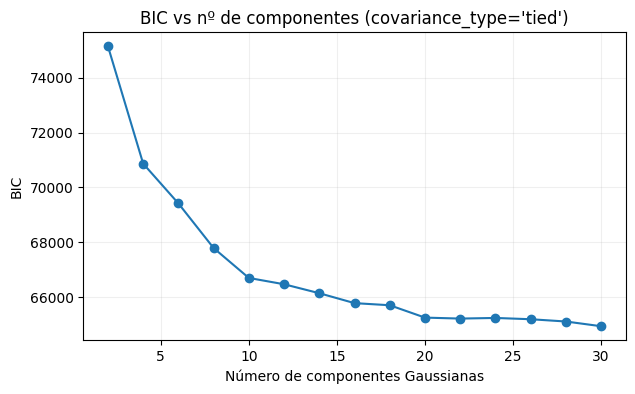

Número de componentes seleccionado para el ajuste rápido: 30


In [5]:
# Búsqueda rápida con 3 componentes principales, 5000 imágenes y covarianza tied
gmm_components_to_try = np.arange(2, 31, 2)

X_pca_3, pca_3, bic_scores_3 = gmm_vs_gaussian_components(
    X,
    gmm_components_to_try=gmm_components_to_try,
    subsample_size=5_000,
    pca_components=3,
    cov_type="tied",
    seed=0,
    verbose=True,
)

best_n_gaussians_3 = int(gmm_components_to_try[np.argmin(bic_scores_3)])
print(f"Número de componentes seleccionado para el ajuste rápido: {best_n_gaussians_3}")

### Respuesta 2.a) y 2.b)

La función `gmm_vs_gaussian_components` se completa haciendo dos pasos principales:

1. **Aplicar PCA** para reducir la dimensionalidad de las imágenes y poder ajustar los GMM de forma más rápida.
2. **Calcular el BIC** para distintos números de componentes Gaussianas y elegir el valor más adecuado a partir de esa curva.

En este caso, se trabaja con:
- un subconjunto de **5000 imágenes**,
- las **3 componentes principales**,
- y covarianza de tipo **`tied`**.

**Interpretación de la gráfica:**
- El **BIC** va bajando de forma bastante clara al aumentar el número de componentes.
- A medida que añadimos más Gaussianas, el modelo ajusta mejor la distribución de los datos.
- En la gráfica no se ve un mínimo interno claro antes del final, sino que el valor más bajo aparece en **`30 componentes`**, que es el mayor número probado.

Por tanto, **dentro del rango evaluado, la mejor elección es `30` componentes Gaussianas**, ya que es donde se obtiene el BIC más bajo.
Aunque siguiendo el método del codo, la elección sería un número de componentes de entre `10` y `12`.

**Esto sugiere** que, incluso después de reducir los datos a solo **3 componentes principales**, la estructura de Fashion-MNIST sigue siendo bastante compleja y necesita bastantes Gaussianas para representarse de forma razonable.  
Aun así, como estamos trabajando en un espacio muy reducido, el modelo está capturando sobre todo la **estructura global** de los datos, no todos los detalles finos de las imágenes originales.

**Conclusión:**  
Con esta configuración (**PCA = 3**, subconjunto de 5000 imágenes y covarianza `tied`), el número de componentes más adecuado entre los probados es **30**, porque es el que da el **menor BIC**.

### 2. c) Generación y visualización de imágenes

Ajusta un *GMM* con el número de componentes elegido en el apartado anterior y genera <br> 
nuevas imágenes mediante el sampleo/muestreo de puntos de esta distribución. Para visualizar <br> 
las imágenes muestreadas, recuerda que el GMM se ha ajustado en un espacio de dimensionalidad reducida.

Para su visualización, os recomendamos usar la función `visualize_subset_in_grid` definida <br>
al inicio del notebook.

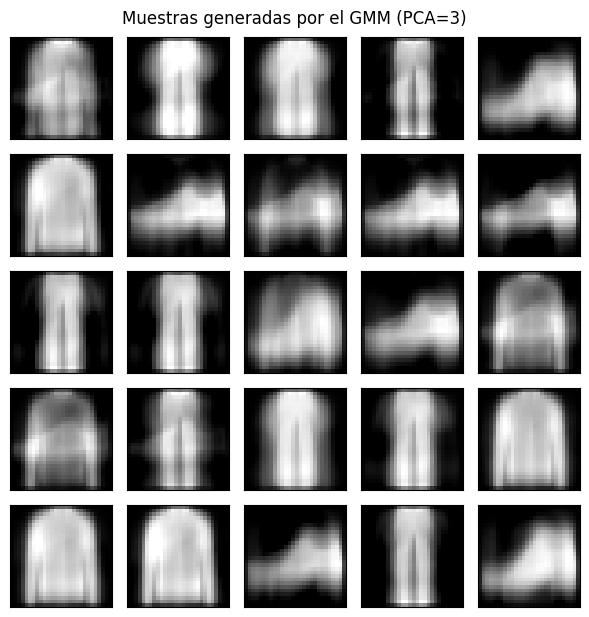

In [6]:
# Ajuste del GMM y muestreo de nuevas imágenes en el espacio PCA de 3 dimensiones
gmm_3 = GaussianMixture(
    n_components=best_n_gaussians_3,
    covariance_type="tied",
    random_state=0,
    n_init=3,
    max_iter=200,
)
gmm_3.fit(X_pca_3)

X_gen_3_pca, _ = gmm_3.sample(25)
X_gen_3 = pca_3.inverse_transform(X_gen_3_pca)
X_gen_3 = np.clip(X_gen_3, 0, 1)

visualize_subset_in_grid(X_gen_3, subset=25, figsize=(6, 6))
plt.suptitle("Muestras generadas por el GMM (PCA=3)", y=1.02)
plt.show()

### Respuesta 2.c)

Las imágenes generadas se obtienen siguiendo estos pasos:

1. se ajusta el **GMM** en el espacio reducido por **PCA**,
2. se muestrean nuevos puntos a partir de esa distribución,
3. y después se aplica `inverse_transform` de PCA para llevarlos otra vez al espacio original de **784 píxeles**.

**Qué se observa en las muestras generadas:**
- Las imágenes sí recuerdan claramente a prendas de **Fashion-MNIST**.
- Se distinguen sobre todo formas parecidas a **camisetas, vestidos o zapatos**.
- Aun así, las imágenes salen bastante **borrosas** y con pocos detalles.
- En muchos casos parecen una especie de **promedio** entre varias prendas similares.

**Interpretación:**  
Esto es normal por varias razones:
- al trabajar con solo **3 componentes principales**, se pierde bastante información,
- y al reconstruir con PCA solo se recupera la parte más global de la imagen, no los detalles finos.

Además, este modelo no tiene en cuenta la **estructura espacial local** de la imagen como lo harían modelos más avanzados de generación de imágenes.

**Conclusión:**  
Aunque las imágenes generadas no son nítidas, sí se ve que el modelo ha aprendido una **aproximación general de la distribución de Fashion-MNIST**, ya que produce muestras coherentes con el tipo de datos del conjunto original.

### 2. d) Genera y visualiza imágenes, empleando una única componente Gaussiana

Con el mismo GMM ajustado, elige una de sus componentes Gaussianas, y samplea/muestrea (y visualiza) <br> 
imágenes correspondientes a esta componente. ¿Qué observas? ¿El tipo de imágenes generadas es diferente?, ¿por qué?


Componente elegida: 7


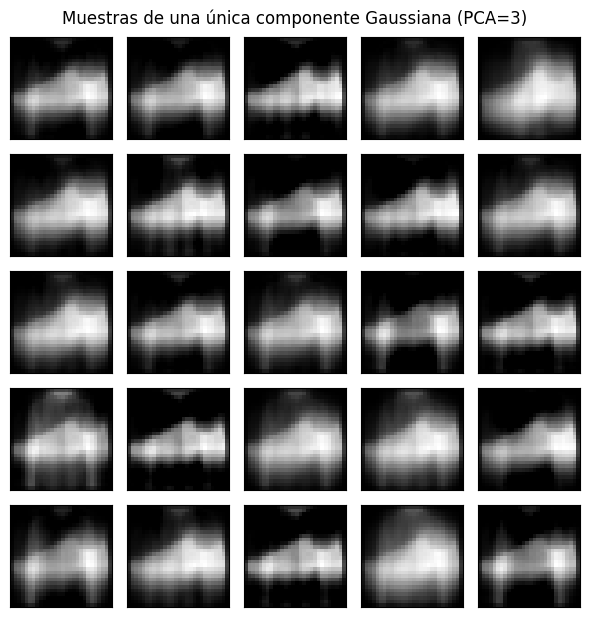

In [7]:
# Muestreo usando una única componente Gaussiana
def covariance_of_component(gmm, component_idx):
    cov_type = gmm.covariance_type
    if cov_type == "full":
        return gmm.covariances_[component_idx]
    if cov_type == "tied":
        return gmm.covariances_
    if cov_type == "diag":
        return np.diag(gmm.covariances_[component_idx])
    if cov_type == "spherical":
        return np.eye(gmm.means_.shape[1]) * gmm.covariances_[component_idx]
    raise ValueError(f"Tipo de covarianza no soportado: {cov_type}")

component_idx_3 = int(np.argmax(gmm_3.weights_))  # componente más representativa
rng = np.random.default_rng(0)
X_comp_3_pca = rng.multivariate_normal(
    mean=gmm_3.means_[component_idx_3],
    cov=covariance_of_component(gmm_3, component_idx_3),
    size=25,
)
X_comp_3 = pca_3.inverse_transform(X_comp_3_pca)
X_comp_3 = np.clip(X_comp_3, 0, 1)

print(f"Componente elegida: {component_idx_3}")
visualize_subset_in_grid(X_comp_3, subset=25, figsize=(6, 6))
plt.suptitle("Muestras de una única componente Gaussiana (PCA=3)", y=1.02)
plt.show()

### Respuesta 2.d)

Sí, **las imágenes cambian bastante** cuando se muestrea una sola componente Gaussiana en vez de toda la mezcla.

En este caso se ve que las muestras son **mucho más parecidas entre sí**.  
Casi todas tienen una forma muy similar, parecida a un **zapato o botín**, y la variación entre imágenes es bastante menor que cuando se generaban muestras desde todo el GMM.

**Por qué pasa esto:**
- Cada componente del **GMM** modela solo una parte concreta del espacio de datos.
- Por eso, al muestrear una única componente, todas las muestras salen alrededor de una misma media y con una variabilidad limitada por esa covarianza.
- En cambio, cuando se muestrea toda la mezcla, intervienen varias componentes distintas y aparece mucha más diversidad.

Esto indica que esa componente concreta del modelo está asociada a una zona del espacio PCA donde predominan imágenes con una morfología parecida. (Como vimos en la práctica anterior)  

En este caso, parece que esa componente ha capturado sobre todo imágenes del tipo **calzado**, por eso casi todas las muestras generadas tienen esa silueta.

**Conclusión:**  
Sí, el tipo de imágenes generadas es diferente.  
La **mezcla completa** produce muestras más variadas, mientras que **una sola componente** genera imágenes más homogéneas y más específicas, porque solo representa una subparte de la distribución total.

### 2. e) Visualización 3D

Visualiza en 3D el GMM ajustado empleando la función `plotly_gmm_results_3d` definida al <br> 
inicio del notebook. ¿En qué espacio se está representando el ajuste?

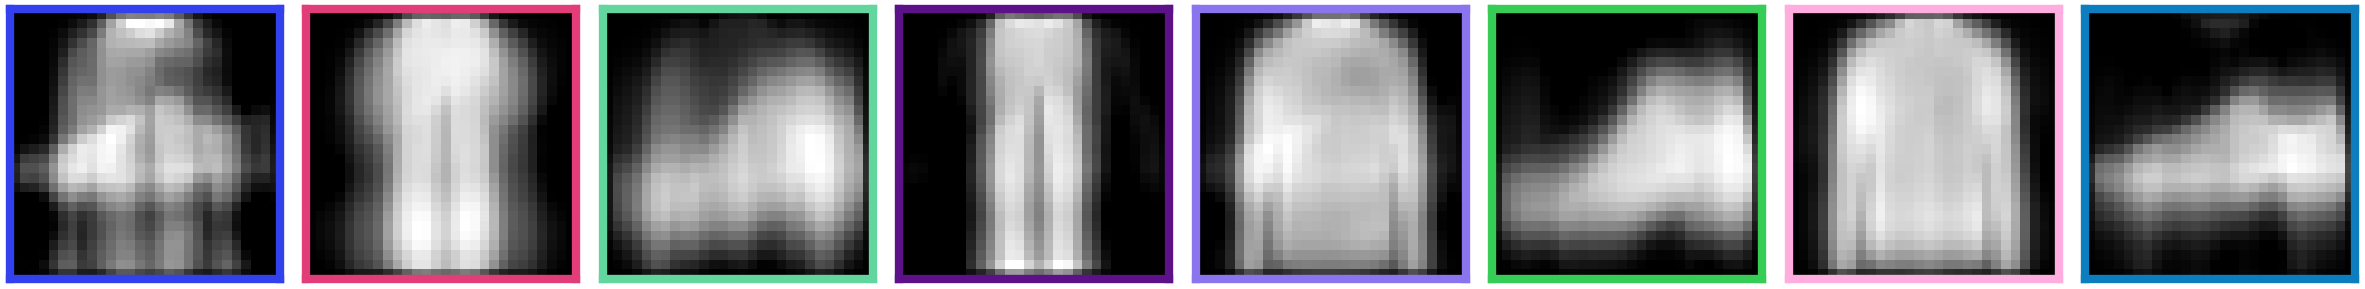

In [8]:
fig = go.Figure()
plotly_gmm_results_3d(fig, X_pca_3, gmm_3, pca=pca_3, std_factors=(1, 2))
fig.update_layout(title="GMM ajustado en el espacio PCA de 3 dimensiones")
fig.show()

### Respuesta 2.e)

La visualización 3D representa el ajuste en el **espacio de características donde se ha ajustado el GMM**, concretamente en las **3 primeras dimensiones del espacio PCA**.

No se están representando directamente las imágenes de 784 píxeles, sino sus coordenadas tras la reducción de dimensionalidad.  
Por eso las elipsoides del GMM reflejan cómo el modelo organiza la densidad en ese espacio latente reducido.

### 2. f) Ajuste de GMM con un mayor (y apropiado) número de componentes principales

Por último, repite el proceso anterior--desde el apartado b) hasta el e), empleando un número <br> 
de componentes principales razonable para no perder tanta información. Siguiendo el mismo <br>
criterio de antes, ¿ha cambiado el número de componentes Gaussianas a emplear? ¿Por qué?

# imágenes originales: 70000
# imágenes seleccionadas aleatoriamente: 5000
Reducción de dimensionalidad con PCA: 784 -> 79


100%|██████████| 34/34 [12:02<00:00, 21.26s/it]


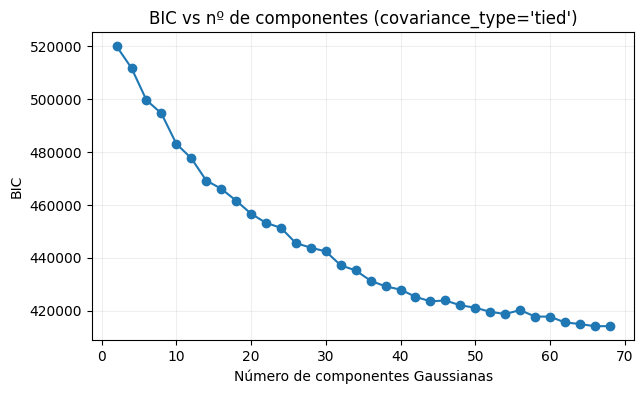

Número de componentes seleccionado con PCA al 90%: 66
Dimensión resultante tras PCA: 79


In [10]:
# Repetimos el proceso reteniendo mucha más información con PCA
gmm_components_to_try_hd = np.arange(2, 70, 2)

X_pca_hd, pca_hd, bic_scores_hd = gmm_vs_gaussian_components(
    X,
    gmm_components_to_try=gmm_components_to_try_hd,
    subsample_size=5_000,
    pca_components=0.90,   # conserva el 90% de la varianza
    cov_type="tied",
    seed=0,
    verbose=True,
)

best_n_gaussians_hd = int(gmm_components_to_try_hd[np.argmin(bic_scores_hd)])
print(f"Número de componentes seleccionado con PCA al 90%: {best_n_gaussians_hd}")
print(f"Dimensión resultante tras PCA: {X_pca_hd.shape[1]}")

In [11]:
# Ajuste final con más componentes principales conservadas
gmm_hd = GaussianMixture(
    n_components=best_n_gaussians_hd,
    covariance_type="tied",
    random_state=0,
    n_init=3,
    max_iter=200,
)
gmm_hd.fit(X_pca_hd)
print("GMM final ajustado correctamente.")

GMM final ajustado correctamente.


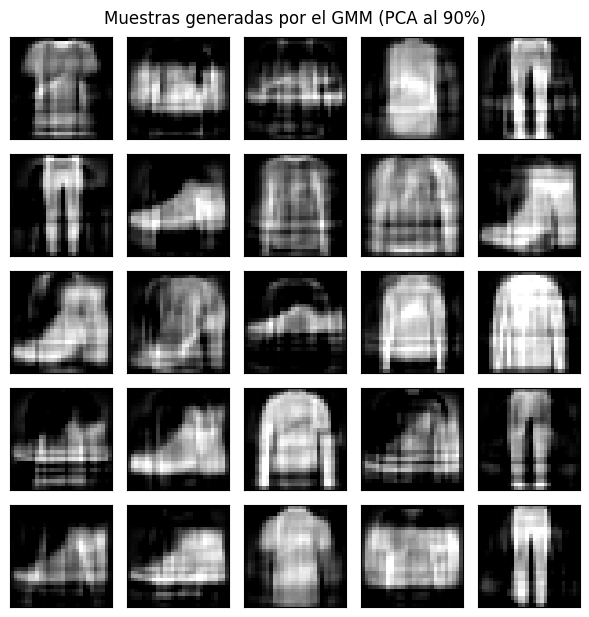

In [12]:
# Muestreo de imágenes desde la mezcla completa
X_gen_hd_pca, _ = gmm_hd.sample(25)
X_gen_hd = pca_hd.inverse_transform(X_gen_hd_pca)
X_gen_hd = np.clip(X_gen_hd, 0, 1)

visualize_subset_in_grid(X_gen_hd, subset=25, figsize=(6, 6));
plt.suptitle("Muestras generadas por el GMM (PCA al 90%)", y=1.02)
plt.show()

Componente elegida: 43


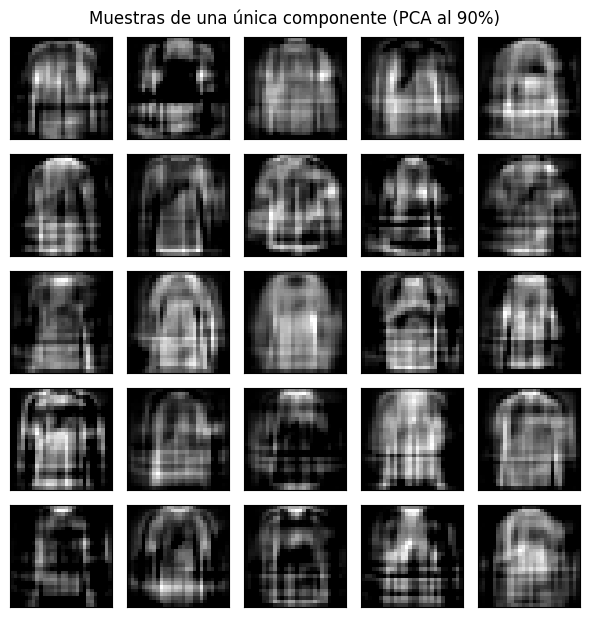

In [13]:
# Muestreo desde una sola componente en el ajuste final
component_idx_hd = int(np.argmax(gmm_hd.weights_))
rng = np.random.default_rng(0)
X_comp_hd_pca = rng.multivariate_normal(
    mean=gmm_hd.means_[component_idx_hd],
    cov=covariance_of_component(gmm_hd, component_idx_hd),
    size=25,
)
X_comp_hd = pca_hd.inverse_transform(X_comp_hd_pca)
X_comp_hd = np.clip(X_comp_hd, 0, 1)

print(f"Componente elegida: {component_idx_hd}")
visualize_subset_in_grid(X_comp_hd, subset=25, figsize=(6, 6));
plt.suptitle("Muestras de una única componente (PCA al 90%)", y=1.02)
plt.show()

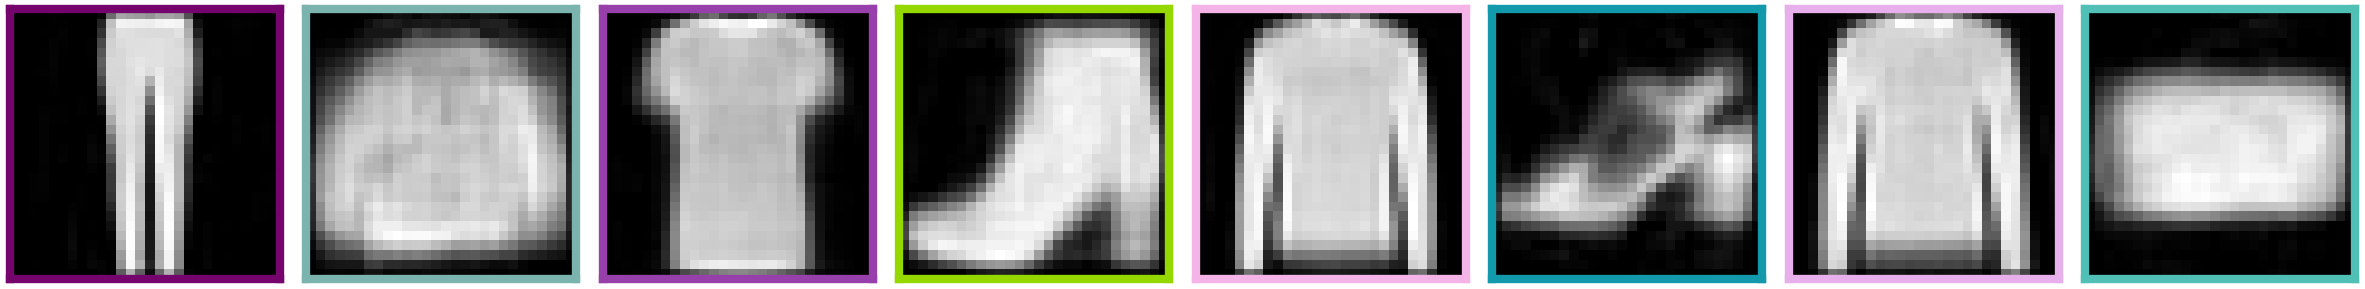

In [14]:
fig = go.Figure()
plotly_gmm_results_3d(fig, X_pca_hd, gmm_hd, pca=pca_hd, std_factors=(1, 2))
fig.update_layout(title="GMM ajustado con PCA al 90% de varianza")
fig.show()

### Respuesta 2.f)

Al repetir el proceso conservando más información con PCA, el número de componentes Gaussianas a usar **sí cambia en la práctica**, o al menos **30 deja de parecer un valor claramente suficiente**.

Cuando solo se probaban hasta **30 componentes**, el BIC seguía bajando y la gráfica quedaba **más parecida a una recta descendente que a una curva con un mínimo claro**.  
Por eso, en ese punto no se podía decir con seguridad que **30** fuera el mejor número de componentes, sino solo que era el mejor **dentro del rango probado**.

Al ampliar la búsqueda a más componentes, el BIC sigue disminuyendo, aunque cada vez más despacio. Esto indica que:
- añadir más Gaussianas sigue mejorando el ajuste,
- pero la mejora es cada vez menor,
- y el mínimo real probablemente está más allá de 30.

Por tanto, **siguiendo el mismo criterio de antes (elegir el menor BIC), el número de componentes sí cambia**, porque ahora el mejor valor pasa a ser el último que se haya probado en la nueva búsqueda, no 30.

**¿Por qué ocurre esto?**  
Porque al conservar más componentes principales con PCA, se mantiene más información de las imágenes y la distribución de los datos es más compleja. Para modelarla bien, el GMM necesita más componentes Gaussianas.

**Conclusión:**  
Sí, el número de componentes a emplear cambia respecto a la búsqueda inicial.  
El valor **30** no parecía un mínimo claro, ya que la curva del BIC seguía bajando casi de forma continua, más como una recta descendente que como una curva con codo o mínimo definido. Por eso, al ampliar el rango, se ve que el modelo todavía mejora con más componentes.

### 2. g) Opcional

## Conclusiones

En esta segunda parte de la práctica se ha utilizado **GMM como estimador de densidad y modelo generativo** para aproximar la distribución de imágenes de **Fashion-MNIST**. Para hacer viable el ajuste del modelo, ha sido necesario reducir la dimensionalidad mediante **PCA** y trabajar con un subconjunto de imágenes.

En la configuración rápida, empleando **5000 imágenes**, **3 componentes principales** y covarianza de tipo **`tied`**, la reducción de dimensionalidad ha conservado aproximadamente un **53.31% de la varianza**. En este caso, el criterio **BIC** ha seguido mejorando hasta el máximo valor probado, por lo que el mejor modelo dentro del rango evaluado ha sido el de **30 componentes Gaussianas**. Esto indica que incluso en un espacio muy reducido, la distribución de Fashion-MNIST sigue siendo compleja y requiere varias componentes para aproximarse de forma razonable.

Las imágenes generadas a partir del GMM son visualmente plausibles, pero presentan un aspecto **suavizado o borroso**, algo esperable porque el modelo genera muestras de una distribución aproximada y, además, parte de la información original se pierde al proyectar y reconstruir los datos con PCA. Aun así, el modelo es capaz de capturar la estructura global de las prendas y producir nuevas muestras coherentes con el conjunto de entrenamiento.

Cuando se muestrean imágenes desde **una única componente Gaussiana**, las muestras resultan más homogéneas entre sí. Esto confirma que cada componente del GMM modela una región concreta del espacio latente, es decir, una subestructura de la distribución total. La mezcla completa ofrece mayor diversidad, mientras que una sola componente produce ejemplos más específicos.

Al repetir el proceso conservando el **90% de la varianza** con PCA, la dimensionalidad resultante ha aumentado hasta **79 componentes principales**. Sin embargo, dentro del rango analizado, el **BIC ha vuelto a seleccionar 30 componentes**. Esto sugiere que la complejidad intrínseca de Fashion-MNIST sigue siendo alta incluso en una representación más rica, y también que podría ser necesario explorar un rango mayor de componentes para comprobar si el mínimo real de BIC aparece más allá de 30.

En conclusión, esta parte de la práctica demuestra que **GMM puede utilizarse no solo para agrupar, sino también para modelar distribuciones y generar nuevos datos**. No obstante, también se observa su limitación en tareas de generación de imágenes: aunque produce muestras razonables, estas pierden nitidez y detalle frente a las imágenes originales. Aun así, el ejercicio resulta muy útil para comprender la relación entre **reducción de dimensionalidad, modelado probabilístico y generación de datos sintéticos**.